Developing tests for this code

- Unit tests and integration tests
- Ideally fast-running, but also realistically capture data variation
- Chappel Allerton park - small enough to be quick

In [43]:
import sys
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path().absolute().parent / 'src'))

import park_vga


In [44]:
boundaries_file = "test_data_england/Leeds_pp_or_g_cmb.geojson"

lidar_dtm = "test_data_england/DTM"
lidar_dsm = "test_data_england/DSM"

output_path = "test_outputs"

In [45]:
park_n = park_vga.workflow.find_park_n("Chapel Allerton Park", boundaries_file)

In [46]:
park_n

353

In [47]:
results = park_vga.workflow.workflow_eng(boundaries_file, park_n, lidar_dtm, lidar_dsm, output_path, return_results=True)

Output directory already exists at test_outputs
Park ID: LEEDS_945491c73c1c
Park ID for file name: leeds_945491c73c1c
Define park grid.
Load park tiles
Finding tile names from park geometry
Calculating grid refs
[(430885.41992692224, 437280.3589293043), (430885.41992692224, 437631.61221827124), (430544.1449808032, 437631.61221827124), (430544.1449808032, 437280.3589293043)]
Grid refs for corners: ['SE33nw', 'SE33nw', 'SE33nw', 'SE33nw']
Tile name(s): {'SE33nw'} 
Finding file paths for these tiles
Paths found: 
DTM paths: ['test_data_england/DTM/SE33nw_DTM_2m.tif'] 
DSM paths: ['test_data_england/DSM/SE33nw_FZ_DSM_2m.tif']
Files found for park 1
Created 517 pointy-top hexagons (10m vertical spacing)
Loading 1 DSM and 1 DTM files
DSM valid pixels: 6250000 of 6250000 (100.0%)
DTM valid pixels: 6250000 of 6250000 (100.0%)
Output shape: (176, 171), Height range: -0.0m to 25.1m
Start calculating visibility. This will take a few mins
Calculating visibility for 517 points
Processing point 1/51

In [57]:
len(results)

2

In [58]:
visibility_results = results[0]
foliage_results = results[1]

In [61]:
foliage_results.columns

Index(['geometry', 'max_height', 'mean_height', 'std_height', 'count_pixels',
       'percent_cover', 'percent_above_0.1m', 'low_level_<0.5',
       'mid_level_0.5-2', 'tall_2+'],
      dtype='str')

In [50]:
visibility_results.shape

(350, 4)

<Axes: >

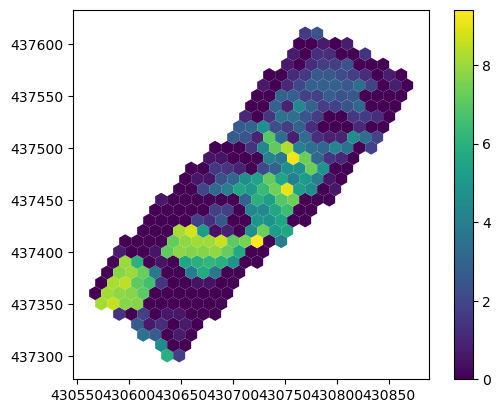

In [51]:
visibility_results.plot(column="visibility_pct", cmap='viridis', legend=True)

In [52]:
foliage_results.shape

(350, 10)

Going to check that the foliage raster looks correct

<Axes: >

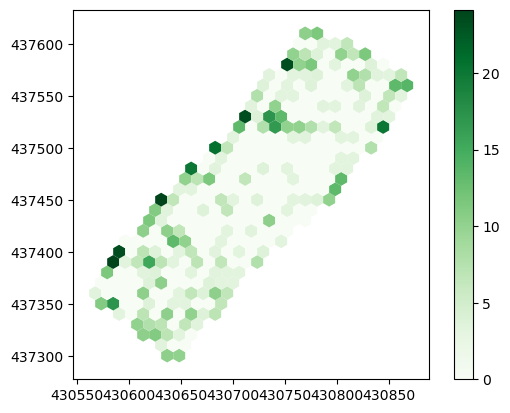

In [53]:
foliage_results.plot(column="low_level_<0.5", cmap='Greens', legend=True)

<Axes: >

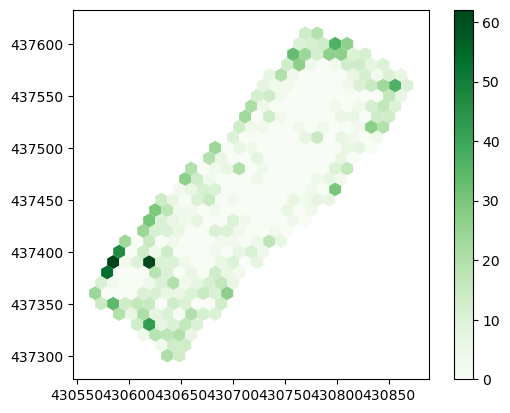

In [54]:
foliage_results.plot(column="mid_level_0.5-2", cmap='Greens', legend=True)

<Axes: >

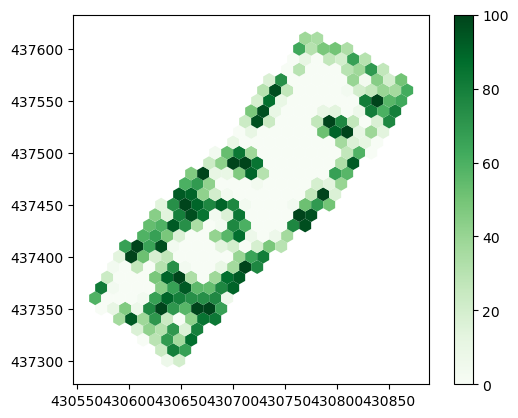

In [55]:
foliage_results.plot(column="tall_2+", cmap='Greens', legend=True)

In [56]:
foliage_results.shape

(350, 10)